In [ ]:
# NOTE (2026-06-03): Removed legacy unpacked variables Y11..Y42 from simulate
# call sites because simulate currently returns only 7 values:
# (time, C_a, C_o, C_v, C_so, Temp, X). Also fixed one call missing index.
# Example before:
# time1, C_a1, C_o1, C_v1, C_so1, Temp1, X1, Y11, Y21, Y31, Y41 = simulate(...)
# Example now:
# time1, C_a1, C_o1, C_v1, C_so1, Temp1, X1 = simulate(...)

# this code is based on 
# https://github.com/Yazdan-Babazadeh/Socio-Climate-model

Simulating scenario: Baseline
Running Baseline with parameters: {'C_s0': 1500, 'C_veg0': 550, 'C_at0': 596, 'C_ao0': 150000.0, 'K_a': 1.773e+20, 'K_p': 0.184, 'K_A': 8703900000.0, 'K_mm': 1.478, 'K_c': 2.9e-05, 'K_m': 0.00012, 'T_0': 288.15, 'K_r': 0.092, 'E_a': 54.83, 'R': 8.314, 'K_sr': 0.034, 'K_b': 157.072, 'K_t': 0.092, 'F_0': 0.025, 'xi': 0.3, 'zeta': 50, 'kappa': 0.05, 'beta': 1, 'delta': 1, 'H': 0.5915, 'P_0': 140000000000.0, 'L': 43655, 'A': 0.225, 'S': 1368, 'c': 4.69e+23, 'sigma': 5.67e-08, 'a_E': 510100000000000.0, 'f_max': 5, 'omega': 3, 'T_c': 2.5, 'epsilon_max': 7, 's': 50, 'r_0': 5, 'x0': 0.95, 'f_gtm': 83259000000000.0, 'tau_CH4': 0.0231, 'tp': 10, 'tf': 25}
Simulating scenario: Kappa02
Running Kappa02 with parameters: {'C_s0': 1500, 'C_veg0': 550, 'C_at0': 596, 'C_ao0': 150000.0, 'K_a': 1.773e+20, 'K_p': 0.184, 'K_A': 8703900000.0, 'K_mm': 1.478, 'K_c': 2.9e-05, 'K_m': 0.00012, 'T_0': 288.15, 'K_r': 0.092, 'E_a': 54.83, 'R': 8.314, 'K_sr': 0.034, 'K_b': 157.072, 'K_t'

c:\Users\lukas\OneDrive\Uni\Master\Masterarbeit\Socio-Climate-model\plotting.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


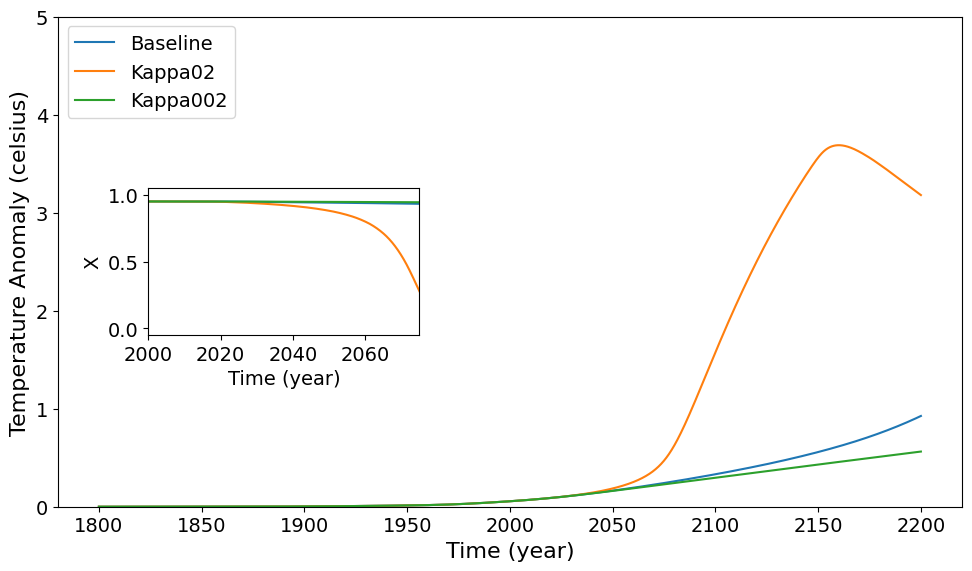

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plotting import *
from sweeps import *

plot_all()

In [2]:
# panel A and D
k = np.linspace(0, 0.2, 50)
r_max = np.linspace(0, 5, 50)
max_info = sweep_auc_diff_over_k_rmax(k, r_max, t_critical=3, index=2)
plot_contour(
    k,
    r_max,
    max_info,
    "K",
    r"$R_{\mathrm{max}}$",
    "Difference in Area Under the Curve Vs $R_{\mathrm{max}}$ and Social Learning Rate",
    "Difference in Area Under the Curve (AUC)",
)

TypeError: simulate() takes from 0 to 1 positional arguments but 6 were given

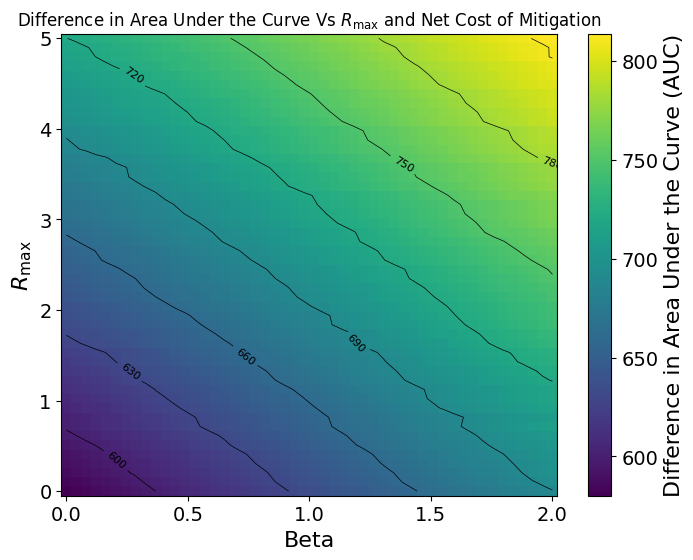

In [4]:
# panel B,E
beta = np.linspace(0, 2, 50)
r_max = np.linspace(0, 5, 50)
max_info = sweep_auc_over_beta_rmax(beta, r_max, k=0.01, delta=1, t_critical=2, index=2)
plot_contour(
    beta,
    r_max,
    max_info,
    "Beta",
    r"$R_{\mathrm{max}}$",
    "Difference in Area Under the Curve Vs $R_{\mathrm{max}}$ and Net Cost of Mitigation",
    "Difference in Area Under the Curve (AUC)",
)

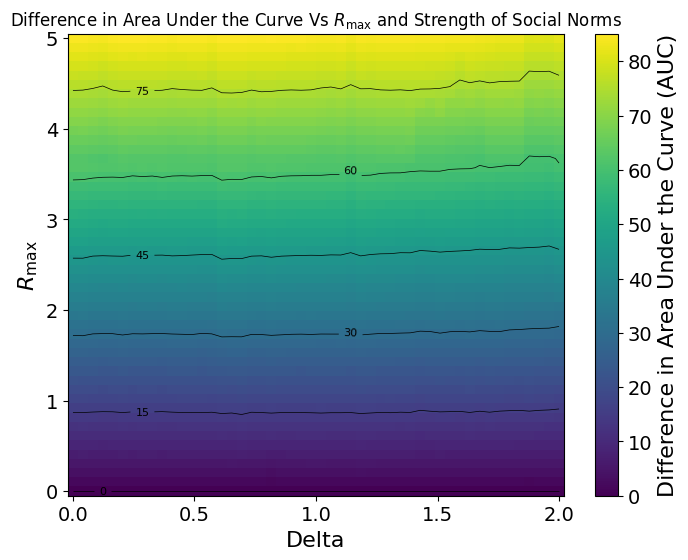

In [2]:
# panel C,F
delta = np.linspace(0, 2, 50)
r_max = np.linspace(0, 5, 50)
max_info = sweep_auc_diff_over_delta_rmax(delta, r_max, k=0.01, beta=1, t_critical=3, index=2)
plot_contour(
    delta,
    r_max,
    max_info,
    "Delta",
    r"$R_{\mathrm{max}}$",
    "Difference in Area Under the Curve Vs $R_{\mathrm{max}}$ and Strength of Social Norms",
    "Difference in Area Under the Curve (AUC)",
)

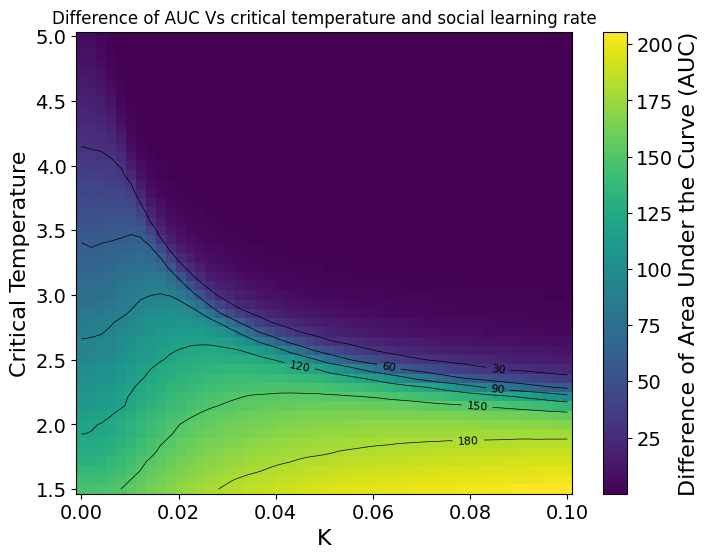

In [3]:
# figure 5
k = np.linspace(0, 0.1, 50)
t_critical = np.linspace(1.5, 5, 50)
max_info = sweep_auc_diff_over_k_tcritical(k, t_critical, r_max=5, index=2)
plot_contour(
    k,
    t_critical,
    max_info,
    "K",
    "Critical Temperature",
    "Difference of AUC Vs critical temperature and social learning rate",
    "Difference of Area Under the Curve (AUC)",
)

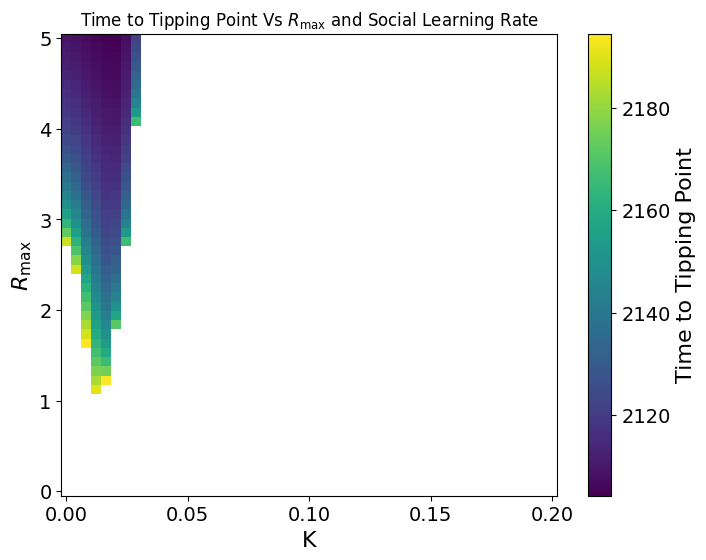

In [4]:
# figure 3
k = np.linspace(0, 0.2, 50)
r_max = np.linspace(0, 5, 50)
max_info = sweep_tipping_year_over_k_rmax(k, r_max, t_critical=3, index=2, threshold=1.1)
x_mesh, y_mesh = np.meshgrid(k, r_max)
plt.figure(figsize=(8, 6))
plt.pcolormesh(x_mesh, y_mesh, max_info, shading="auto")
plt.colorbar(label="Time to Tipping Point")
plt.xlabel("K", fontsize=16)
plt.ylabel(r"$R_{\mathrm{max}}$", fontsize=16)
plt.title("Time to Tipping Point Vs $R_{\mathrm{max}}$ and Social Learning Rate", fontsize=12)
plt.show()

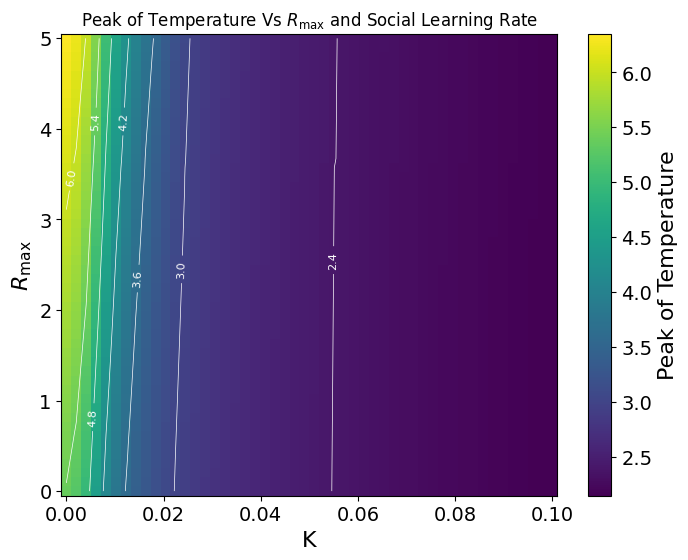

In [5]:
# figure 4
k = np.linspace(0, 0.1, 50)
r_max = np.linspace(0, 5, 50)
max_info = sweep_peak_temp_over_k_rmax(k, r_max, t_critical=3, index=2)
plot_contour(
    k,
    r_max,
    max_info,
    "K",
    r"$R_{\mathrm{max}}$",
    "Peak of Temperature Vs $R_{\mathrm{max}}$ and Social Learning Rate",
    "Peak of Temperature",
    contour_color="w",
)

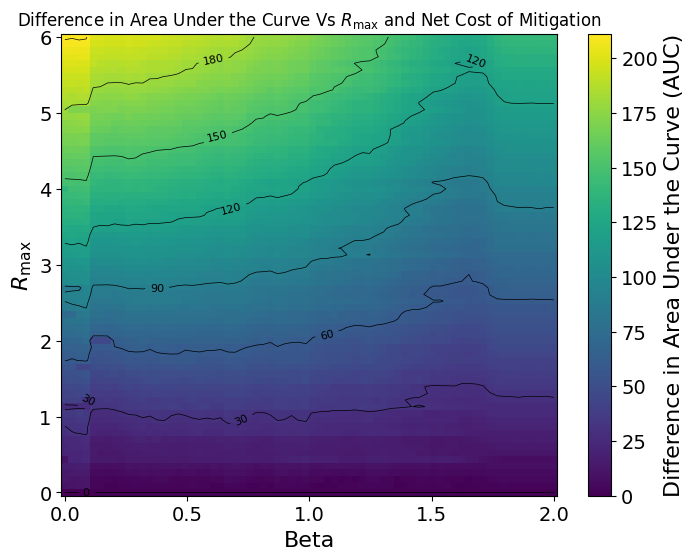

In [6]:
# figure 6
beta = np.linspace(0, 2, 70)
r_max = np.linspace(0, 6, 70)
max_info = sweep_auc_diff_over_beta_rmax(beta, r_max, k=0.1, delta=3, t_critical=2, index=2)
plot_contour(
    beta,
    r_max,
    max_info,
    "Beta",
    r"$R_{\mathrm{max}}$",
    "Difference in Area Under the Curve Vs $R_{\mathrm{max}}$ and Net Cost of Mitigation",
    "Difference in Area Under the Curve (AUC)",
)